In [74]:
!pip install pandas numpy matplotlib seaborn scikit-learn -q

In [75]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

In [76]:
import zipfile
import os

zip_file = "archive (32).zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print(os.listdir("dataset"))

['Country-data.csv', 'data-dictionary.csv']


In [77]:
df = pd.read_csv("dataset/Country-data.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## Dataset Loading Observation

The country dataset was successfully loaded into the notebook environment. The dataset contains socio-economic indicators for multiple countries, including child mortality, income, GDP per capita, life expectancy, exports, imports, and health expenditure.

The initial inspection confirms that the dataset structure is suitable for clustering analysis and country segmentation.

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [79]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [80]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


## Dataset Exploration Observation

The dataset was examined using `.info()`, `.describe()`, and missing value checks.

Key observations:

- The dataset contains both numerical and categorical variables.
- The `country` column serves as an identifier and will not be used for clustering.
- Numerical features represent economic, demographic, and health indicators.
- Basic statistical summaries provide insight into variable distributions and ranges.

In [81]:
print("Dataset Shape:", df.shape)

print("\nColumns:")

for col in df.columns:
    print(col)

Dataset Shape: (167, 10)

Columns:
country
child_mort
exports
health
imports
income
inflation
life_expec
total_fer
gdpp


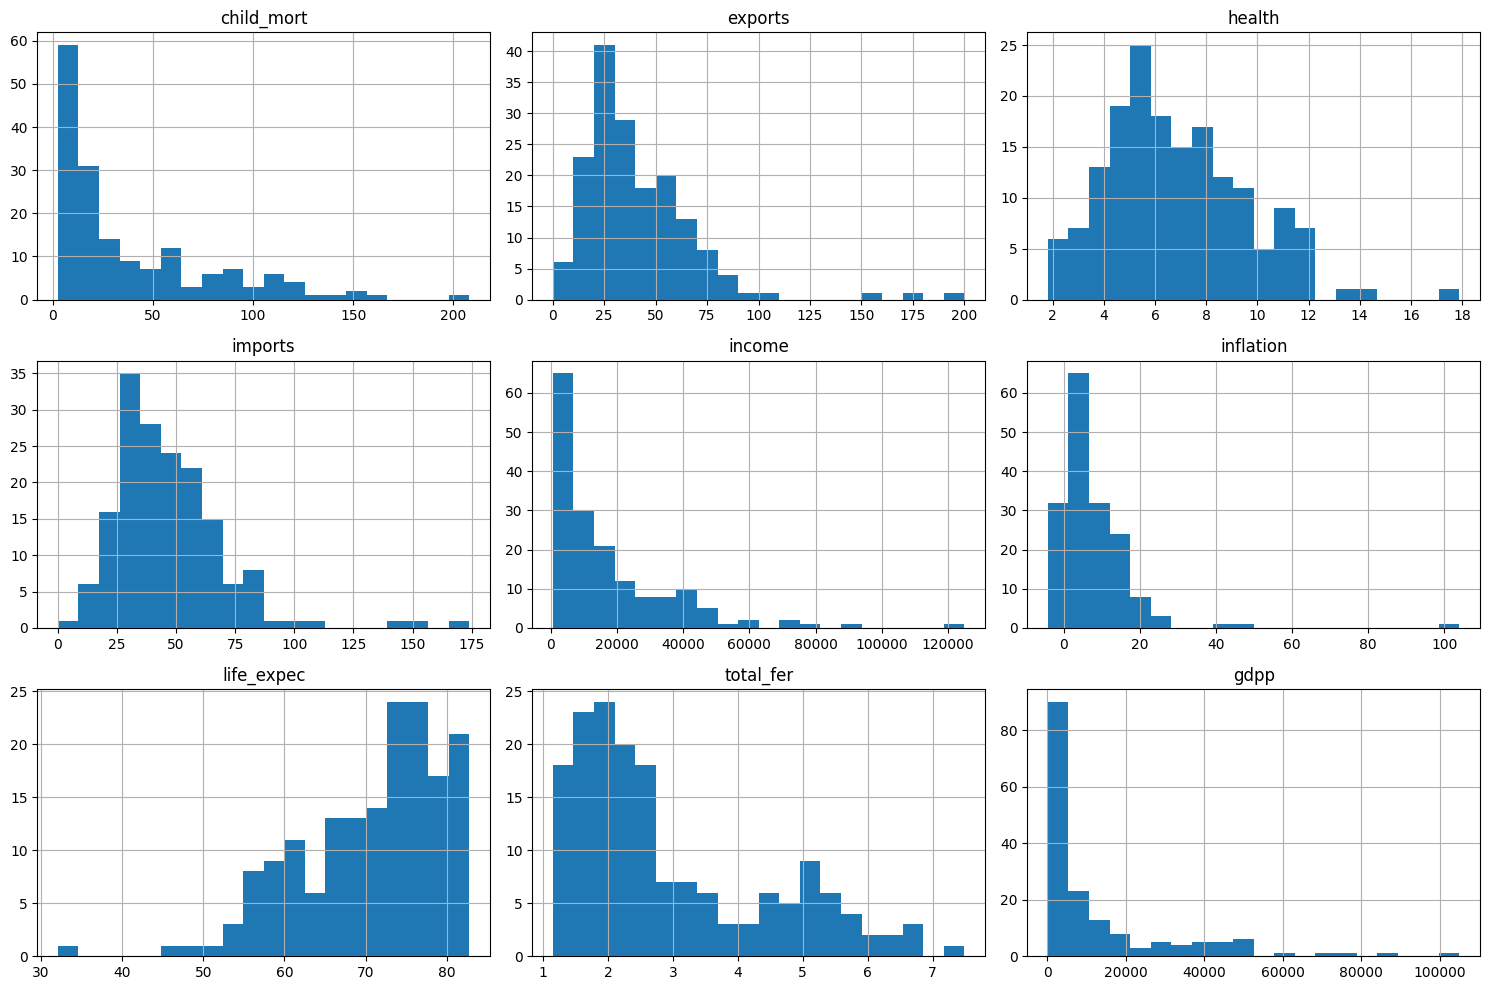

In [82]:
df.drop('country', axis=1).hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()

plt.show()

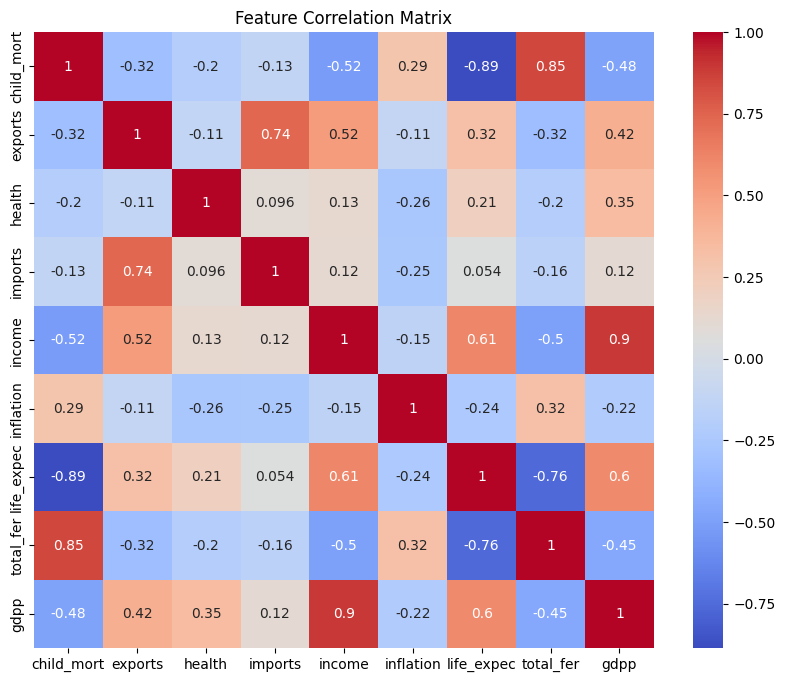

In [83]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.drop('country', axis=1).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Matrix")

plt.show()

In [84]:
df.columns = df.columns.str.strip()

df.drop_duplicates(inplace=True)

for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

df.fillna(df.median(numeric_only=True), inplace=True)

print("Remaining Missing Values:")
print(df.isnull().sum())

Remaining Missing Values:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


## Data Cleaning Observation

A data cleaning pipeline was applied to improve data quality.

The following preprocessing steps were completed:

- Removed leading and trailing whitespace from column names.
- Removed duplicate records.
- Converted all numerical features to numeric data types.
- Replaced missing values using median imputation.

After cleaning, no missing values remained in the dataset, ensuring reliable downstream analysis.

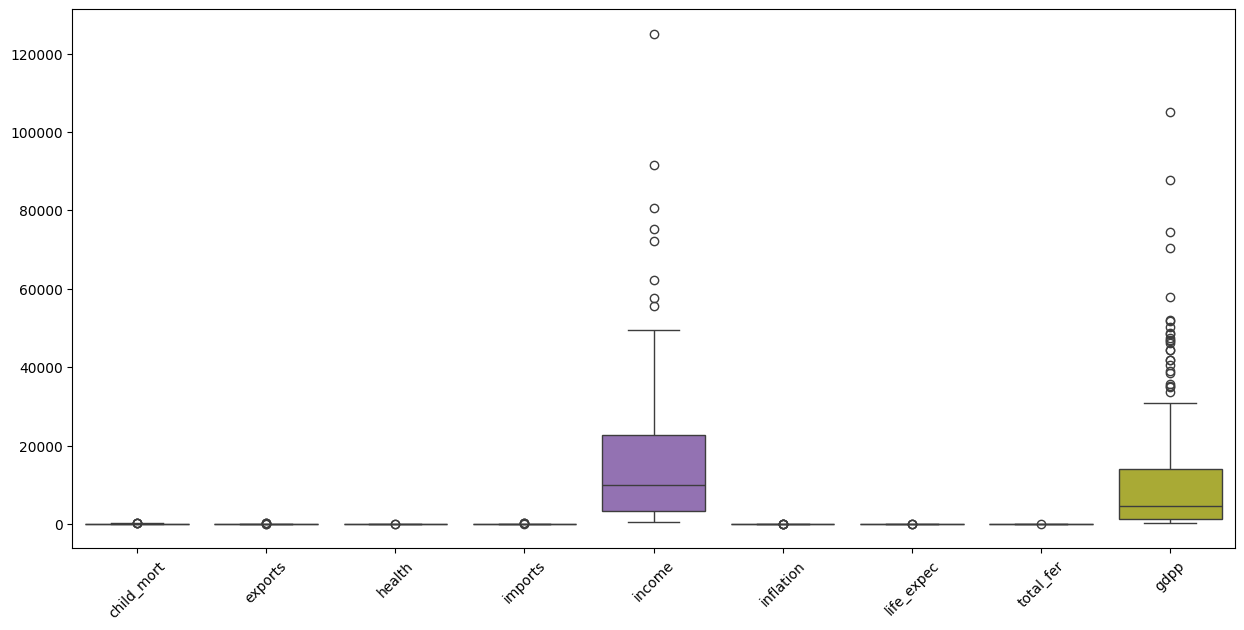

In [85]:
plt.figure(figsize=(15,7))

sns.boxplot(
    data=df.drop('country', axis=1)
)

plt.xticks(rotation=45)

plt.show()

In [86]:
country_names = df['country']

X = df.drop('country', axis=1)

print(X.head())

   child_mort  exports  health  imports  income  inflation  life_expec  \
0        90.2     10.0    7.58     44.9    1610       9.44        56.2   
1        16.6     28.0    6.55     48.6    9930       4.49        76.3   
2        27.3     38.4    4.17     31.4   12900      16.10        76.5   
3       119.0     62.3    2.85     42.9    5900      22.40        60.1   
4        10.3     45.5    6.03     58.9   19100       1.44        76.8   

   total_fer   gdpp  
0       5.82    553  
1       1.65   4090  
2       2.89   4460  
3       6.16   3530  
4       2.13  12200  


## Feature Selection Observation

The `country` column was separated from the dataset because it is a categorical identifier rather than a measurable feature.

Only continuous socio-economic indicators were retained for clustering analysis, ensuring that distance calculations are based solely on numerical attributes.

In [87]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(167, 9)


## Feature Scaling Observation

StandardScaler was applied to normalize all numerical features.

Scaling ensures that variables with large magnitudes, such as GDP and income, do not dominate variables with smaller ranges, such as fertility rates or inflation.

This step is essential because clustering algorithms rely on distance calculations.

In [88]:
scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

scaled_df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


In [89]:
inertias = []

k_values = range(2, 11)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertias.append(kmeans.inertia_)

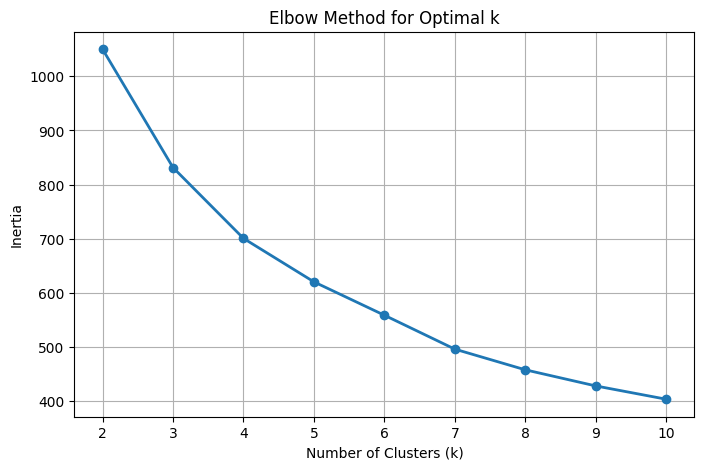

In [90]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    inertias,
    marker='o',
    linewidth=2
)

plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')

plt.grid(True)

plt.show()

## Elbow Method Observation

The Elbow Method was used to determine the optimal number of clusters by evaluating inertia values for k ranging from 2 to 10.

The resulting curve shows a noticeable reduction in inertia up to approximately k = 3, after which the rate of improvement begins to decrease.

Based on the elbow pattern, three clusters were selected for the final K-Means model.

In [91]:
best_k = 3

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = kmeans_labels

print(df[['country','KMeans_Cluster']].head())

               country  KMeans_Cluster
0          Afghanistan               1
1              Albania               2
2              Algeria               2
3               Angola               1
4  Antigua and Barbuda               2


## K-Means Clustering Observation

A K-Means clustering model was trained using three clusters.

Each country was assigned to one of the three segments based on similarities in socio-economic indicators.

The resulting cluster labels will be used to analyze country development levels and identify meaningful economic groupings.

In [92]:
sil_score = silhouette_score(
    X_scaled,
    kmeans_labels
)

print("Silhouette Score:", round(sil_score,4))

Silhouette Score: 0.2833


## Clustering Performance Observation

The K-Means model achieved a Silhouette Score of 0.2833.

A positive silhouette score indicates that countries within the same cluster are more similar to each other than to countries in neighboring clusters.

Although the separation is not perfect, the score suggests acceptable clustering performance for real-world socio-economic data.

In [93]:
df['KMeans_Cluster'].value_counts()

,count
KMeans_Cluster,
2,84
1,47
0,36


## Cluster Distribution Observation

The distribution of countries across clusters was examined.

The results indicate that countries are grouped into three segments of varying sizes, reflecting different socio-economic profiles.

This distribution confirms that the K-Means model successfully partitioned the dataset into meaningful groups.

In [94]:
cluster_summary = df.groupby(
    'KMeans_Cluster'
).mean(
    numeric_only=True
)

cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
KMeans_Cluster,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381


## Cluster Profile Observation

Average socio-economic indicators were calculated for each cluster.

The summary statistics reveal substantial differences among clusters in terms of:

- Child mortality
- Income
- GDP per capita
- Life expectancy
- Fertility rates

These differences indicate that the clusters represent distinct development levels ranging from highly developed economies to lower-income countries.

In [95]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = dbscan_labels

print(df['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64


In [96]:
print("Unique DBSCAN Labels:")
print(sorted(df['DBSCAN_Cluster'].unique()))

Unique DBSCAN Labels:
[np.int64(-1), np.int64(0)]


In [97]:
print("Number of DBSCAN Clusters:",
      len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0))

print("Number of Noise Points:",
      list(dbscan_labels).count(-1))

Number of DBSCAN Clusters: 1
Number of Noise Points: 30


## DBSCAN Clustering Observation

A DBSCAN model was implemented using:

- eps = 1.5
- min_samples = 5

The algorithm identified one primary dense cluster and several outlier countries.

Specifically:

- 137 countries were assigned to the main cluster.
- 30 countries were classified as noise (outliers).

This suggests that while many countries share similar socio-economic characteristics, some countries exhibit significantly different development patterns.

In [98]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(167, 2)


## PCA Dimensionality Reduction Observation

Principal Component Analysis (PCA) was applied to reduce the dataset from nine dimensions to two principal components.

The transformed dataset retained the most important sources of variation while enabling visual representation of country segments in two-dimensional space.

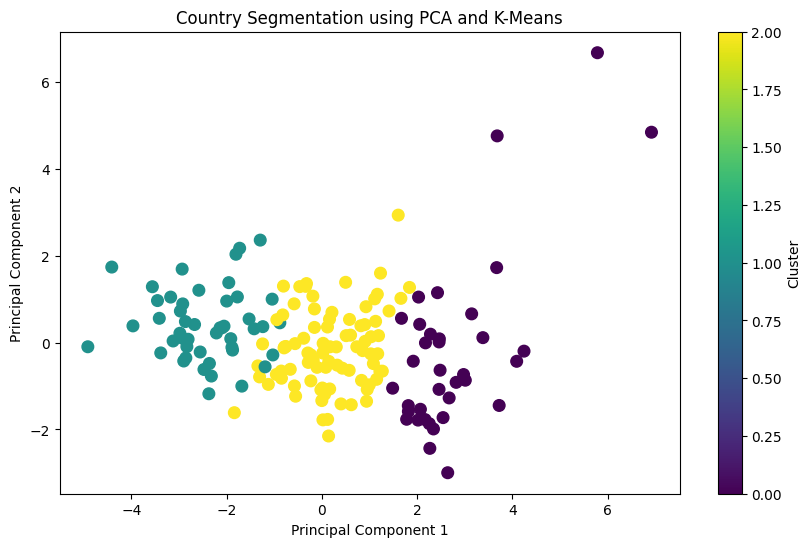

In [99]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=kmeans_labels,
    cmap='viridis',
    s=70
)

plt.title('Country Segmentation using PCA and K-Means')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.colorbar(scatter,label='Cluster')

plt.show()

## PCA Visualization Observation

The PCA scatterplot visualizes country segments identified by the K-Means algorithm.

Three distinct color-coded clusters are visible, demonstrating meaningful separation between country groups.

The visualization confirms that socio-economic indicators such as income, GDP per capita, mortality rates, and life expectancy effectively distinguish countries with different development profiles.

# Section 14: Country Segmentation Insights

### Observation 1: High-Mortality Cluster

Cluster 1 represents the least developed countries, characterized by the highest child mortality rate (92.96), lowest GDP per capita (1922), lowest income levels (3942), and lowest life expectancy (59.19 years). These countries face significant socio-economic and healthcare challenges.

### Observation 2: Top-Tier Economic Zone

Cluster 0 represents highly developed economies with the highest average income (45672), highest GDP per capita (42494), longest life expectancy (80.13 years), and lowest child mortality rate (5.0). These countries demonstrate strong economic and healthcare performance.

### Observation 3: Developing Economies

Cluster 2 consists of developing countries with moderate income levels (12306), GDP per capita (6486), and life expectancy (72.81 years). These countries exhibit improving socio-economic conditions compared to Cluster 1 but remain below the development level of Cluster 0.

### Observation 4: Cluster Separation

The PCA visualization demonstrates meaningful separation among the three clusters, indicating that socio-economic indicators effectively distinguish different levels of national development.

### Observation 5: Model Stability

The K-Means model achieved a silhouette score of 0.2833, indicating acceptable cluster cohesion and separation. This supports the suitability of using three clusters for country segmentation.

# Additional Classification and Ensemble Learning Analysis

To further analyze the clustered countries, Random Forest and XGBoost are trained to predict cluster membership based on socio-economic indicators.

In [100]:
df['KMeans_Cluster']

,KMeans_Cluster
0,1
1,2
2,2
3,1
4,2
...,...
162,2
163,2
164,2
165,1


In [101]:
from sklearn.model_selection import train_test_split

X_cls = X.copy()

y_cls = df['KMeans_Cluster']

X_train, X_test, y_train, y_test = train_test_split(
    X_cls,
    y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

print(X_train.shape)
print(X_test.shape)

(133, 9)
(34, 9)


In [102]:
!pip install xgboost lightgbm -q

In [103]:
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [104]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred, average='weighted'))

Random Forest Results
Accuracy: 1.0
F1 Score: 1.0


In [105]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGBoost Results")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("F1 Score:", f1_score(y_test, xgb_pred, average='weighted'))

XGBoost Results
Accuracy: 0.9705882352941176
F1 Score: 0.9702344095532949


In [106]:
lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

lgbm.fit(X_train, y_train)

lgbm_pred = lgbm.predict(X_test)

print("LightGBM Results")
print("Accuracy:", accuracy_score(y_test, lgbm_pred))
print("F1 Score:", f1_score(y_test, lgbm_pred, average='weighted'))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000042 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 395
[LightGBM] [Info] Number of data points in the train set: 133, number of used features: 9
[LightGBM] [Info] Start training from score -1.523053
[LightGBM] [Info] Start training from score -1.279431
[LightGBM] [Info] Start training from score -0.685657
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furt

In [107]:
results = pd.DataFrame({
    'Model':[
        'Random Forest',
        'XGBoost',
        'LightGBM'
    ],
    'Accuracy':[
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, lgbm_pred)
    ],
    'F1 Score':[
        f1_score(y_test, rf_pred, average='weighted'),
        f1_score(y_test, xgb_pred, average='weighted'),
        f1_score(y_test, lgbm_pred, average='weighted')
    ]
})

results.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy,F1 Score
0,Random Forest,1.000000,1.000000
2,LightGBM,1.000000,1.000000
1,XGBoost,0.970588,0.970234


In [108]:
best_model = results.loc[
    results['Accuracy'].idxmax()
]

print(best_model)

Model       Random Forest
Accuracy              1.0
F1 Score              1.0
Name: 0, dtype: object


## Supervised Learning Extension

The original dataset does not contain a predefined target variable. Therefore, K-Means cluster assignments were used as pseudo-labels to create a supervised learning task.

Random Forest, XGBoost, and LightGBM classifiers were trained to predict cluster membership, enabling comparative evaluation using accuracy, precision, recall, and F1-score metrics.